In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image
import os
import cv2

In [ ]:
model_path = "/content/drive/MyDrive/RICE_MODEL_YOLO/yolov8_model_backup/weights/best.pt"

In [ ]:
model = YOLO(model_path)

In [ ]:
result = model.predict("/content/drive/MyDrive/RICE_MODEL_YOLO/test/images/139_png_jpg.rf.c09cc909479b1848d20d932740d7e0a8.jpg", conf=0.5)


image 1/1 /content/drive/MyDrive/RICE_MODEL_YOLO/test/images/139_png_jpg.rf.c09cc909479b1848d20d932740d7e0a8.jpg: 640x640 51 Chalkys, 4 Cleans, 1 Discolored, 1 Immature, 333.5ms
Speed: 9.7ms preprocess, 333.5ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
result[0].names

{0: 'Broken',
 1: 'Chalky',
 2: 'Clean',
 3: 'Damaged',
 4: 'Discolored',
 5: 'Immature',
 6: 'Organic Foreign Matters'}

Label Distribution:
Broken: 0.00%
Chalky: 89.47%
Clean: 7.02%
Damaged: 0.00%
Discolored: 1.75%
Immature: 1.75%
Organic Foreign Matters: 0.00%


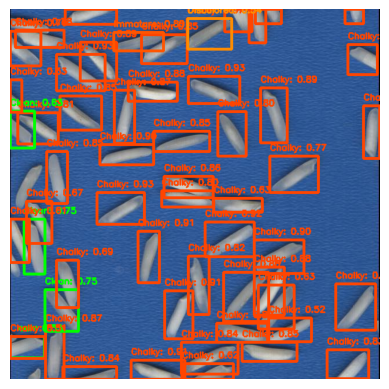

In [15]:
import collections

# Function to draw custom annotations
def custom_annotate_image(image, boxes, names, colors=None, show_labels=True):
    annotated_img = image.copy()
    for box in boxes:
        x1, y1, x2, y2 = [int(i) for i in box.xyxy[0]]
        label_id = int(box.cls[0])
        label_name = names[label_id]
        confidence = float(box.conf[0])

        # Choose color based on label or use a default color
        color = colors.get(label_id, (255, 0, 0)) if colors else (255, 0, 0)

        # Draw bounding box
        cv2.rectangle(annotated_img, (x1, y1), (x2, y2), color, 4)

        # Add label and confidence
        if show_labels:
            label = f"{label_name}: {confidence:.2f}"
            cv2.putText(annotated_img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return annotated_img

# Define custom colors for each label (optional)
custom_colors = {
    0: (0, 0, 255),       # Broken – Bright Red
    1: (0, 69, 255),      # Chalky – Dark Orange
    2: (0, 255, 0),       # Clean – Green
    3: (0, 102, 204),     # Damaged – Orange-Red
    4: (0, 140, 255),     # Discolored – Orange
    5: (0, 85, 255),      # Immature – Reddish Orange
    6: (0, 50, 150)       # Organic Foreign Matters – Muted Red
}


# Use the custom annotation function
annotated_image = custom_annotate_image(result[0].orig_img, result[0].boxes, result[0].names, colors=custom_colors, show_labels=True)

# Convert BGR to RGB for matplotlib display
annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

# Get the predicted labels
labels = result[0].boxes.cls.tolist()
label_names = result[0].names

# Count the occurrences of each label
label_counts = collections.Counter(labels)

# Calculate percentages and prepare report
total_labels = len(labels)
report_lines = ["Label Distribution:"]
for label_id in sorted(label_names.keys()): # Iterate through all possible labels
    count = label_counts.get(label_id, 0) # Get count, default to 0 if label not present
    percentage = (count / total_labels) * 100 if total_labels > 0 else 0
    report_lines.append(f"{label_names[label_id]}: {percentage:.2f}%")

# Print the report
print("\n".join(report_lines))

# Display the image
plt.imshow(annotated_image_rgb)
plt.axis('off')

plt.show()

In [ ]:
import collections

# Function to draw custom annotations
def custom_annotate_image(image, boxes, names, colors=None, show_labels=True):
    annotated_img = image.copy()
    for box in boxes:
        x1, y1, x2, y2 = [int(i) for i in box.xyxy[0]]
        label_id = int(box.cls[0])
        label_name = names[label_id]
        confidence = float(box.conf[0])

        # Choose color based on label or use a default color
        color = colors.get(label_id, (255, 0, 0)) if colors else (255, 0, 0)

        # Draw bounding box
        cv2.rectangle(annotated_img, (x1, y1), (x2, y2), color, 2)

        # Add label and confidence
        if show_labels:
            label = f"{label_name}: {confidence:.2f}"
            cv2.putText(annotated_img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return annotated_img

# Define custom colors for each label (optional)
custom_colors = {
    0: (0, 0, 255),       # Broken - Red in BGR
    1: (0, 165, 255),     # Chalky - Orange in BGR
    2: (0, 255, 0),       # Clean - Green in BGR
    3: (128, 0, 128),     # Damaged - Purple in BGR
    4: (0, 255, 255),     # Discolored - Yellow in BGR
    5: (255, 255, 0),     # Immature - Cyan in BGR
    6: (105, 105, 105)    # Organic Foreign Matters - Dark Gray in BGR
}


def detect_and_report(image_input, model, custom_colors=None, show_labels=True, return_img=False):
    """
    Performs object detection on an image and reports label percentages and counts.

    Args:
        image_input: Path to the image file or a BGR image array.
        model: The loaded YOLO model.
        custom_colors: Dictionary of custom colors for annotations.
        show_labels: Whether to display labels on the annotated image.
        return_img: If True, returns the annotated image with the report as title.
    """
    if isinstance(image_input, str):
        # If input is a path, read the image
        image = cv2.imread(image_input)
    elif isinstance(image_input, np.ndarray):
        # If input is a numpy array (image), use it directly
        image = image_input
    else:
        raise ValueError("Invalid input type. Please provide an image path or a BGR image array.")

    # Perform detection
    results = model.predict(image)

    # Use the custom annotation function
    annotated_image = custom_annotate_image(image, results[0].boxes, results[0].names, colors=custom_colors, show_labels=show_labels)

    # Convert BGR to RGB for matplotlib display
    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

    # Get the predicted labels
    labels = results[0].boxes.cls.tolist()
    label_names = results[0].names

    # Count the occurrences of each label
    label_counts = collections.Counter(labels)

    # Calculate percentages and prepare report
    total_labels = len(labels)
    report_lines = ["Label Distribution:"]
    for label_id in sorted(label_names.keys()): # Iterate through all possible labels
        count = label_counts.get(label_id, 0) # Get count, default to 0 if label not present
        percentage = (count / total_labels) * 100 if total_labels > 0 else 0
        report_lines.append(f"{label_names[label_id]}: {percentage:.2f}% ({count})")

    report_string = "\n".join(report_lines)

    # Print the report
    print(report_string)

    # Display the image
    plt.imshow(annotated_image_rgb)
    plt.axis('off')
    plt.title(report_string) # Set the report as the title
    plt.show()

    if return_img:
        # Create a copy of the annotated image to add the title
        image_with_title = annotated_image.copy()
        # Add the report as text on the image
        y_offset = 30
        for line in report_lines:
            cv2.putText(image_with_title, line, (10, y_offset), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            y_offset += 20
        return image_with_title


0: 640x640 54 Chalkys, 6 Cleans, 4 Discoloreds, 3 Immatures, 434.5ms
Speed: 5.6ms preprocess, 434.5ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Label Distribution:
Broken: 0.00% (0)
Chalky: 80.60% (54)
Clean: 8.96% (6)
Damaged: 0.00% (0)
Discolored: 5.97% (4)
Immature: 4.48% (3)
Organic Foreign Matters: 0.00% (0)


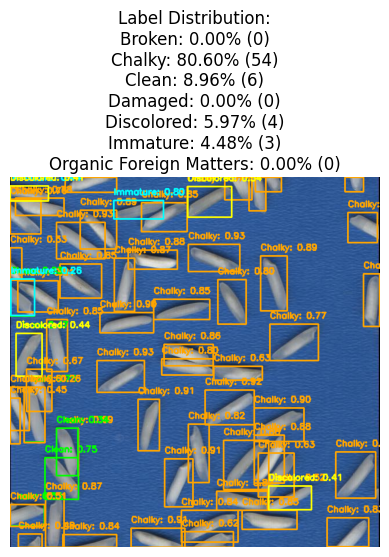

In [ ]:
detect_and_report("/content/drive/MyDrive/RICE_MODEL_YOLO/test/images/139_png_jpg.rf.c09cc909479b1848d20d932740d7e0a8.jpg", model, custom_colors)

In [ ]:
from glob import glob
from tqdm import tqdm

In [ ]:
test_images_path = "/content/drive/MyDrive/RICE_MODEL_YOLO/test/images"
test_images = glob(test_images_path + "/*")

In [ ]:
test_images_filtered = [image for image in test_images if "_IM_" not in image]
len(test_images_filtered)

10

In [ ]:
output_folder = "/content/drive/MyDrive/RICE_MODEL_YOLO/test/results"

# Create the output folder if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

for image_path in tqdm(test_images_filtered, desc="Processing Images"):
    # Run detection and get the annotated image
    annotated_img_with_title = detect_and_report(image_path, model, custom_colors, return_img=True)

    # Get the base filename
    base_filename = os.path.basename(image_path)

    # Create the output path
    output_path = os.path.join(output_folder, base_filename)

    # Save the annotated image
    cv2.imwrite(output_path, annotated_img_with_title)

print(f"Processed {len(test_images_filtered)} images and saved results to {output_folder}")

Output hidden; open in https://colab.research.google.com to view.